# Этап 1. Подключение к PostgreSQL и загрузка таблиц

In [1]:
# Импортируем библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Импортируем таблицы данных
users = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-users.csv')
transactions = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-transactions.csv')
reviews = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-reviews.csv')
products = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-products.csv')
orders = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-orders.csv')
order_items = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-order_items.csv')
categories = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-categories.csv')

In [3]:
# Проверяем датафреймы
users.info()
transactions.info()
reviews.info()
products.info()
orders.info()
order_items.info()
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111300 entries, 0 to 111299
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            111300 non-null  object
 1   name               111300 non-null  object
 2   email              111300 non-null  object
 3   phone              111300 non-null  object
 4   user_type          111300 non-null  object
 5   registration_date  111300 non-null  object
 6   is_active          111300 non-null  bool  
dtypes: bool(1), object(6)
memory usage: 5.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811200 entries, 0 to 811199
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    811200 non-null  object 
 1   user_id           811200 non-null  object 
 2   amount            811200 non-null  float64
 3   transaction_type  811200 non-null  object 
 4   transa

# Этап 2. Подготовка данных

In [4]:
# Соберем таблицы в один словарь для удобства
tables = {
    'categories': categories,
    'order_items': order_items,
    'orders': orders,
    'products': products,
    'reviews': reviews,
    'transactions': transactions,
    'users': users
}

In [5]:
# Поиск дубликатов
for name,df in tables.items():
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"Таблица '{name}': найдено {dup_count} дубликатов.")
        df.drop_duplicates(inplace = true)
        print(f"  -> Удалено. Осталось строк: {len(df)}")
    else:
        print(f"Таблица '{name}' : дубликатов не найдено")

Таблица 'categories' : дубликатов не найдено
Таблица 'order_items' : дубликатов не найдено
Таблица 'orders' : дубликатов не найдено
Таблица 'products' : дубликатов не найдено
Таблица 'reviews' : дубликатов не найдено
Таблица 'transactions' : дубликатов не найдено
Таблица 'users' : дубликатов не найдено


In [6]:
# Приводим столбцы с датами к типуц datetime
users['registration_date'] = pd.to_datetime(users['registration_date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
#Проверяем
print(users['registration_date'].dtype)
print(transactions['transaction_date'].dtype)
print(reviews['review_date'].dtype)
print(orders['order_date'].dtype) 

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [7]:
# Находим и заменяем строки с отрицательной ценой на 0
negative_prices_count = (products['price'] < 0).sum()
if negative_prices_count > 0:
    print(f"Найдено {negative_prices_count} строк с отрицательной ценой. Заменяем на 0...")
    products.loc[products['price'] < 0, 'price'] = 0
    print("Замена выполнена.")
else:
    print("Строк с отрицательной ценой не найдено.")



Строк с отрицательной ценой не найдено.


In [8]:
# Добавляем новый столбец и функцию для категоризации

def get_rating_category(rating):
    if rating >= 4.5:
        return 'High'
    elif rating >= 4:
        return 'Medium'
    else:
        return 'Low'
        
reviews['rating_category'] = reviews['rating'].apply(get_rating_category)
print(reviews[['rating', 'rating_category']].head())

   rating rating_category
0       2             Low
1       3             Low
2       2             Low
3       2             Low
4       4          Medium


In [9]:
# Ищем пропуски

for name, df in tables.items():
    print(f'\n{name}:')
    missing = df.isna().sum()
    print(missing[missing > 0])


categories:
parent_category_id    885
dtype: int64

order_items:
Series([], dtype: int64)

orders:
Series([], dtype: int64)

products:
Series([], dtype: int64)

reviews:
Series([], dtype: int64)

transactions:
Series([], dtype: int64)

users:
Series([], dtype: int64)


# Этап 3. Исследовательский анализ

Базовая статистика:
              price  stock_quantity
count  52100.000000    52100.000000
mean     506.569939      500.620461
std      285.605499      287.761399
min       10.020000        0.000000
25%      260.072500      254.000000
50%      507.810000      502.000000
75%      754.180000      747.000000
max      999.990000     1000.000000


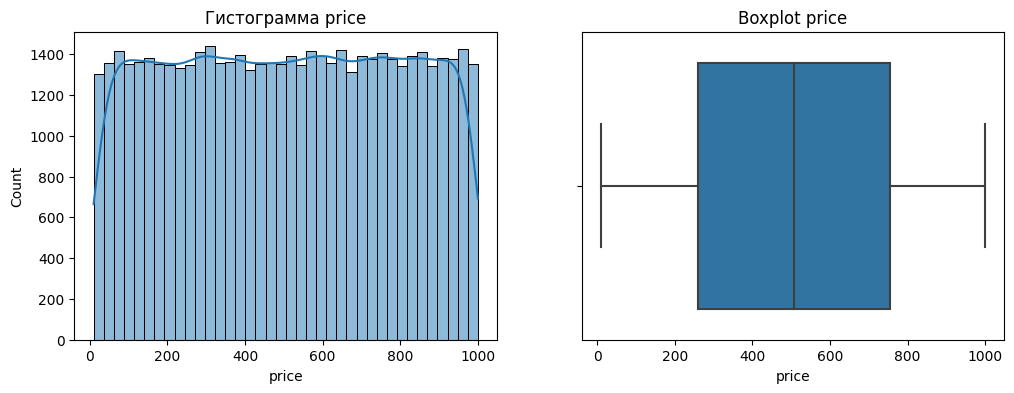

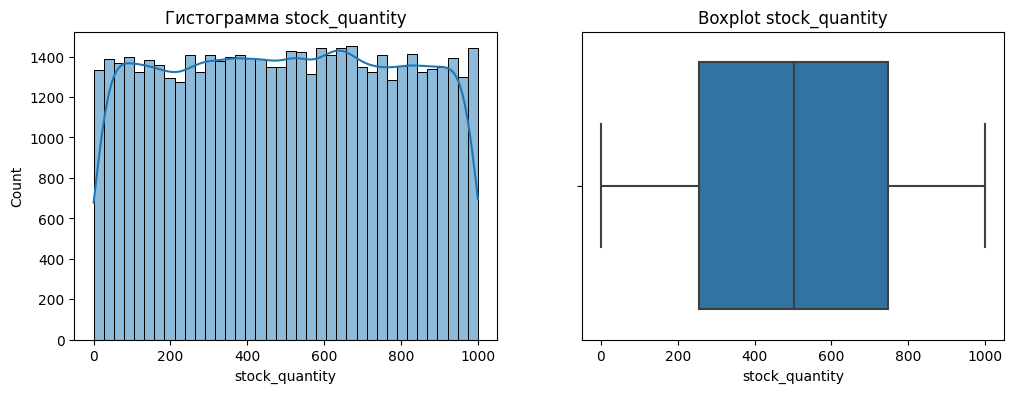

Корреляционная матрица:
                   price  stock_quantity
price           1.000000        0.000815
stock_quantity  0.000815        1.000000


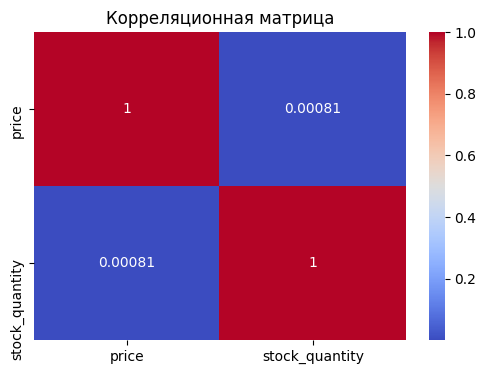

In [10]:
# Напишем универсальную функцию  для статистики и графиков
def analyze_columns(df, columns):
    # Базовая статистика
    print("Базовая статистика:")
    print(df[columns].describe())

    # Гистограммы и Boxplot
    for column in columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[column], kde=True, ax=axes[0])
        axes[0].set_title(f'Гистограмма {column}')

        sns.boxplot(x=df[column], ax=axes[1])
        axes[1].set_title(f'Boxplot {column}')

        plt.show()
    # Корреляционная матрица
    print("Корреляционная матрица:")
    print(df[columns].corr())

    plt.figure(figsize=(6, 4))
    sns.heatmap(df[columns].corr(), annot=True, cmap='coolwarm')
    plt.title("Корреляционная матрица")
    plt.show()

    
analyze_columns(products, ['price','stock_quantity'])

# Этап 4. Выгрузка данных

In [12]:
# Преобразование даты
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Фильтрация
filtered_orders = orders[
    (orders['order_date'] >= '2025-01-01') &
    (orders['order_date'] <= '2025-06-01')
]

# Выгрузка
filtered_orders.to_csv(
    'filtered_orders.csv',
    sep=';',
    index=False
)

# Проверка
print("Таблица успешно выгружена.")
print(f"Размер данных: {filtered_orders.shape}")
print(f"Количество строк: {len(filtered_orders)}")
print(f"Количество столбцов: {filtered_orders.shape[1]}")

Таблица успешно выгружена.
Размер данных: (246456, 5)
Количество строк: 246456
Количество столбцов: 5
